# 01 — Data Audit

Initial audit of the Recife meteorological dataset used in the Rain Nowcasting project.

## Objectives

This notebook verifies:

- dataset dimensions;
- available columns;
- data types;
- missing values;
- duplicated records;
- temporal coverage;
- timestamp continuity;
- precipitation distribution;
- basic meteorological consistency.

No data will be modified in this notebook.

In [72]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [73]:
DATA_PATH = Path("../data/processed/DataFrameRecife.csv")

In [74]:
DATA_PATH.exists()

True

In [75]:
df = pd.read_csv(
    DATA_PATH,
    sep=",",
    encoding="utf-8"
)

df.head()
df.shape

(8279, 18)

In [76]:
df.head()

,\nData,HORA (UTC)\n,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)\n","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)\n",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)\n,PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)\n,"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)\n",TEMPERATURA DO PONTO DE ORVALHO (°C)\n,TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)\n,TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)\n,TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)\n,TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)\n,UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)\n,UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)\n,"UMIDADE RELATIVA DO AR, HORARIA (%)\n","VENTO, DIREÇÃO HORARIA (gr) (° (gr))\n","VENTO, RAJADA MAXIMA (m/s)\n","VENTO, VELOCIDADE HORARIA (m/s)\n"
0,2018-01-03,13:00,0,"1011,7","1011,8","1011,6","31,5","18,8","32,7","30,1","20,1","18,2",51.0,45.0,47,35.0,"6,1","2,5"
1,2018-01-03,14:00,0,"1011,4","1011,7","1011,4","31,9","20,4",33,"30,5","20,7","18,9",51.0,46.0,51,50.0,"6,3","2,6"
2,2018-01-03,15:00,0,1011,"1011,4",1011,"31,3","20,6","33,3","30,7","21,6","20,2",56.0,47.0,53,62.0,"7,7","2,5"
3,2018-01-03,16:00,0,"1010,3",1011,"1010,3","32,1","20,8","32,6","30,3","21,3","20,1",57.0,49.0,51,67.0,"8,5","2,4"
4,2018-01-03,17:00,0,"1009,7","1010,3","1009,7","31,2","20,6","32,6","30,5","21,2","19,9",54.0,50.0,53,55.0,"8,5","2,2"


In [77]:
df.shape

(8279, 18)

In [78]:
for i, column in enumerate(df.columns):
    print(i, repr(column))

0 '\nData'
1 'HORA (UTC)\n'
2 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)\n'
3 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)\n'
4 'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)\n'
5 'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)\n'
6 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)\n'
7 'TEMPERATURA DO PONTO DE ORVALHO (°C)\n'
8 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)\n'
9 'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)\n'
10 'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)\n'
11 'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)\n'
12 'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)\n'
13 'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)\n'
14 'UMIDADE RELATIVA DO AR, HORARIA (%)\n'
15 'VENTO, DIREÇÃO HORARIA (gr) (° (gr))\n'
16 'VENTO, RAJADA MAXIMA (m/s)\n'
17 'VENTO, VELOCIDADE HORARIA (m/s)\n'


In [79]:
df.dtypes

\nData                                                         str
HORA (UTC)\n                                                   str
PRECIPITAÇÃO TOTAL, HORÁRIO (mm)\n                             str
PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)\n        str
PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)\n              str
PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)\n             str
TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)\n                 str
TEMPERATURA DO PONTO DE ORVALHO (°C)\n                         str
TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)\n                   str
TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)\n                   str
TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)\n             str
TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)\n             str
UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)\n                 float64
UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)\n                 float64
UMIDADE RELATIVA DO AR, HORARIA (%)\n                        i

In [80]:
df.isna().sum()

\nData                                                     0
HORA (UTC)\n                                               0
PRECIPITAÇÃO TOTAL, HORÁRIO (mm)\n                         0
PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)\n    0
PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)\n          0
PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)\n         0
TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)\n             0
TEMPERATURA DO PONTO DE ORVALHO (°C)\n                     0
TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)\n               0
TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)\n               0
TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)\n         0
TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)\n         0
UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)\n                 0
UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)\n                 0
UMIDADE RELATIVA DO AR, HORARIA (%)\n                      0
VENTO, DIREÇÃO HORARIA (gr) (° (gr))\n                     0
VENTO, RAJADA MAXIMA (m/

In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
print(f"Valores ausentes: {df.isna().sum().sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas: 8279
Colunas: 18
Valores ausentes: 0
Linhas duplicadas: 0


In [83]:
df.isna().sum()

\nData                                                     0
HORA (UTC)\n                                               0
PRECIPITAÇÃO TOTAL, HORÁRIO (mm)\n                         0
PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)\n    0
PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)\n          0
PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)\n         0
TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)\n             0
TEMPERATURA DO PONTO DE ORVALHO (°C)\n                     0
TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)\n               0
TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)\n               0
TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)\n         0
TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)\n         0
UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)\n                 0
UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)\n                 0
UMIDADE RELATIVA DO AR, HORARIA (%)\n                      0
VENTO, DIREÇÃO HORARIA (gr) (° (gr))\n                     0
VENTO, RAJADA MAXIMA (m/

In [84]:
df.duplicated().sum()

np.int64(0)

In [85]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
print(f"Valores ausentes: {df.isna().sum().sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas: 8279
Colunas: 18
Valores ausentes: 0
Linhas duplicadas: 0


In [86]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace("\n", "", regex=False)
)

In [87]:
for i, column in enumerate(df.columns):
    print(i, repr(column))

0 'Data'
1 'HORA (UTC)'
2 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'
3 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)'
4 'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)'
5 'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)'
6 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'
7 'TEMPERATURA DO PONTO DE ORVALHO (°C)'
8 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)'
9 'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)'
10 'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)'
11 'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)'
12 'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)'
13 'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)'
14 'UMIDADE RELATIVA DO AR, HORARIA (%)'
15 'VENTO, DIREÇÃO HORARIA (gr) (° (gr))'
16 'VENTO, RAJADA MAXIMA (m/s)'
17 'VENTO, VELOCIDADE HORARIA (m/s)'


In [88]:
df_clean = df.copy()

In [89]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace("\n", "", regex=False)
)

In [90]:
for i, column in enumerate(df_clean.columns):
    print(i, repr(column))

0 'Data'
1 'HORA (UTC)'
2 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'
3 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)'
4 'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)'
5 'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)'
6 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'
7 'TEMPERATURA DO PONTO DE ORVALHO (°C)'
8 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)'
9 'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)'
10 'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)'
11 'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)'
12 'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)'
13 'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)'
14 'UMIDADE RELATIVA DO AR, HORARIA (%)'
15 'VENTO, DIREÇÃO HORARIA (gr) (° (gr))'
16 'VENTO, RAJADA MAXIMA (m/s)'
17 'VENTO, VELOCIDADE HORARIA (m/s)'


## Column Standardization

The original INMET column names are standardized to concise `snake_case` names while preserving their meteorological meaning and units.

In [91]:
column_mapping = {
    "Data": "date",
    "HORA (UTC)": "time_utc",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "precipitation_mm",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "pressure_station_mb",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)": "pressure_max_prev_hour_mb",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)": "pressure_min_prev_hour_mb",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "temperature_c",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)": "dew_point_c",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)": "temperature_max_prev_hour_c",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)": "temperature_min_prev_hour_c",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)": "dew_point_max_prev_hour_c",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)": "dew_point_min_prev_hour_c",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)": "humidity_max_prev_hour_pct",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)": "humidity_min_prev_hour_pct",
    "UMIDADE RELATIVA DO AR, HORARIA (%)": "humidity_pct",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))": "wind_direction_deg",
    "VENTO, RAJADA MAXIMA (m/s)": "wind_gust_ms",
    "VENTO, VELOCIDADE HORARIA (m/s)": "wind_speed_ms",
}

In [92]:
df_clean = df_clean.rename(columns=column_mapping)

In [93]:
for i, column in enumerate(df_clean.columns):
    print(i, column)

0 date
1 time_utc
2 precipitation_mm
3 pressure_station_mb
4 pressure_max_prev_hour_mb
5 pressure_min_prev_hour_mb
6 temperature_c
7 dew_point_c
8 temperature_max_prev_hour_c
9 temperature_min_prev_hour_c
10 dew_point_max_prev_hour_c
11 dew_point_min_prev_hour_c
12 humidity_max_prev_hour_pct
13 humidity_min_prev_hour_pct
14 humidity_pct
15 wind_direction_deg
16 wind_gust_ms
17 wind_speed_ms


In [94]:
df_clean.head()

,date,time_utc,precipitation_mm,pressure_station_mb,pressure_max_prev_hour_mb,pressure_min_prev_hour_mb,temperature_c,dew_point_c,temperature_max_prev_hour_c,temperature_min_prev_hour_c,dew_point_max_prev_hour_c,dew_point_min_prev_hour_c,humidity_max_prev_hour_pct,humidity_min_prev_hour_pct,humidity_pct,wind_direction_deg,wind_gust_ms,wind_speed_ms
0,2018-01-03,13:00,0,"1011,7","1011,8","1011,6","31,5","18,8","32,7","30,1","20,1","18,2",51.0,45.0,47,35.0,"6,1","2,5"
1,2018-01-03,14:00,0,"1011,4","1011,7","1011,4","31,9","20,4",33,"30,5","20,7","18,9",51.0,46.0,51,50.0,"6,3","2,6"
2,2018-01-03,15:00,0,1011,"1011,4",1011,"31,3","20,6","33,3","30,7","21,6","20,2",56.0,47.0,53,62.0,"7,7","2,5"
3,2018-01-03,16:00,0,"1010,3",1011,"1010,3","32,1","20,8","32,6","30,3","21,3","20,1",57.0,49.0,51,67.0,"8,5","2,4"
4,2018-01-03,17:00,0,"1009,7","1010,3","1009,7","31,2","20,6","32,6","30,5","21,2","19,9",54.0,50.0,53,55.0,"8,5","2,2"


## Numeric Type Conversion

Meteorological variables are converted from text representations to numeric values.

The original dataset uses commas as decimal separators, so decimal commas are first replaced by decimal points before numeric conversion.

After conversion, the dataset is checked for missing values introduced during the process.

In [95]:
numeric_columns = [
    "precipitation_mm",
    "pressure_station_mb",
    "pressure_max_prev_hour_mb",
    "pressure_min_prev_hour_mb",
    "temperature_c",
    "dew_point_c",
    "temperature_max_prev_hour_c",
    "temperature_min_prev_hour_c",
    "dew_point_max_prev_hour_c",
    "dew_point_min_prev_hour_c",
    "humidity_max_prev_hour_pct",
    "humidity_min_prev_hour_pct",
    "humidity_pct",
    "wind_direction_deg",
    "wind_gust_ms",
    "wind_speed_ms",
]

for column in numeric_columns:
    df_clean[column] = (
        df_clean[column]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )

    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

print("Numeric conversion completed.")

Numeric conversion completed.


In [96]:
df_clean[numeric_columns].dtypes

precipitation_mm               float64
pressure_station_mb            float64
pressure_max_prev_hour_mb      float64
pressure_min_prev_hour_mb      float64
temperature_c                  float64
dew_point_c                    float64
temperature_max_prev_hour_c    float64
temperature_min_prev_hour_c    float64
dew_point_max_prev_hour_c      float64
dew_point_min_prev_hour_c      float64
humidity_max_prev_hour_pct     float64
humidity_min_prev_hour_pct     float64
humidity_pct                     int64
wind_direction_deg             float64
wind_gust_ms                   float64
wind_speed_ms                  float64
dtype: object

In [97]:
conversion_missing = df_clean[numeric_columns].isna().sum()

conversion_missing[conversion_missing > 0]

Series([], dtype: int64)

In [98]:
conversion_missing[conversion_missing > 0]

Series([], dtype: int64)

## Datetime Construction and Temporal Validation

The date and UTC time columns are combined into a single timezone-aware datetime variable.

This allows the dataset to be sorted chronologically and checked for duplicated timestamps and missing hourly observations.

In [99]:
df_clean["datetime_utc"] = pd.to_datetime(
    df_clean["date"].astype(str)
    + " "
    + df_clean["time_utc"].astype(str),
    format="%Y-%m-%d %H:%M",
    errors="coerce",
    utc=True
)

df_clean[
    ["date", "time_utc", "datetime_utc"]
].head()

,date,time_utc,datetime_utc
0,2018-01-03,13:00,2018-01-03 13:00:00+00:00
1,2018-01-03,14:00,2018-01-03 14:00:00+00:00
2,2018-01-03,15:00,2018-01-03 15:00:00+00:00
3,2018-01-03,16:00,2018-01-03 16:00:00+00:00
4,2018-01-03,17:00,2018-01-03 17:00:00+00:00


In [100]:
df_clean["datetime_utc"].isna().sum()

np.int64(0)

In [101]:
df_clean["datetime_utc"].duplicated().sum()

np.int64(0)

In [102]:
print("First observation:", df_clean["datetime_utc"].min())
print("Last observation:", df_clean["datetime_utc"].max())

First observation: 2018-01-03 13:00:00+00:00
Last observation: 2018-12-31 23:00:00+00:00


### Hourly Continuity

The difference between consecutive timestamps is calculated to identify periods where one or more hourly observations are missing.

In [103]:
df_clean = df_clean.sort_values("datetime_utc").copy()

df_clean["gap_hours"] = (
    df_clean["datetime_utc"]
    .diff()
    .dt.total_seconds()
    .div(3600)
)

temporal_gaps = df_clean[
    df_clean["gap_hours"] > 1
][
    ["datetime_utc", "gap_hours"]
]

temporal_gaps

,datetime_utc,gap_hours
280,2018-01-28 12:00:00+00:00,320.0
538,2018-02-08 11:00:00+00:00,6.0
554,2018-02-09 11:00:00+00:00,9.0
571,2018-02-10 11:00:00+00:00,8.0
589,2018-02-11 11:00:00+00:00,7.0
605,2018-02-12 11:00:00+00:00,9.0
620,2018-02-13 10:00:00+00:00,9.0
636,2018-02-14 10:00:00+00:00,9.0
654,2018-02-15 10:00:00+00:00,7.0
675,2018-02-16 10:00:00+00:00,4.0


In [104]:
print("Number of temporal gaps:", len(temporal_gaps))

Number of temporal gaps: 19


In [105]:
missing_hours_between_observations = int(
    (df_clean.loc[df_clean["gap_hours"] > 1, "gap_hours"] - 1).sum()
)

print(
    "Missing hours between first and last observation:",
    missing_hours_between_observations
)

Missing hours between first and last observation: 420


In [106]:
full_2018_range = pd.date_range(
    start="2018-01-01 00:00",
    end="2018-12-31 23:00",
    freq="h",
    tz="UTC"
)

missing_2018_timestamps = full_2018_range.difference(
    df_clean["datetime_utc"]
)

print("Expected hours in 2018:", len(full_2018_range))
print("Observed hours:", len(df_clean))
print("Missing hours:", len(missing_2018_timestamps))

Expected hours in 2018: 8760
Observed hours: 8279
Missing hours: 481


## Precipitation Analysis

This section evaluates the distribution and frequency of precipitation events in the dataset.

Different rainfall thresholds are inspected to understand how frequent intense rainfall events are before defining the prediction target used by the Machine Learning models.

In [107]:
# Basic precipitation statistics
precipitation = df_clean["precipitation_mm"]

print("=== PRECIPITATION SUMMARY ===")
print(f"Minimum precipitation: {precipitation.min():.2f} mm")
print(f"Maximum precipitation: {precipitation.max():.2f} mm")
print(f"Average precipitation: {precipitation.mean():.2f} mm")
print(f"Median precipitation: {precipitation.median():.2f} mm")
print()

# Rain / no-rain observations
rain_hours = (precipitation > 0).sum()
no_rain_hours = (precipitation == 0).sum()

print("=== RAIN OCCURRENCE ===")
print(f"Hours without rain: {no_rain_hours}")
print(f"Hours with rain: {rain_hours}")
print(f"Percentage of rainy hours: {(rain_hours / len(df_clean)) * 100:.2f}%")
print()

# Frequency at different rainfall thresholds
thresholds = [0.1, 1, 2, 5, 10, 15, 20, 25, 30]

threshold_results = []

for threshold in thresholds:
    count = (precipitation >= threshold).sum()
    percentage = count / len(df_clean) * 100

    threshold_results.append(
        {
            "threshold_mm_h": threshold,
            "observations": count,
            "percentage": percentage,
        }
    )

threshold_df = pd.DataFrame(threshold_results)

print("=== RAINFALL THRESHOLDS ===")
display(threshold_df)

# General descriptive statistics
print("=== DESCRIPTIVE STATISTICS ===")
display(
    df_clean[
        [
            "precipitation_mm",
            "temperature_c",
            "humidity_pct",
            "pressure_station_mb",
            "wind_speed_ms",
            "wind_gust_ms",
        ]
    ].describe().T
)

=== PRECIPITATION SUMMARY ===
Minimum precipitation: 0.00 mm
Maximum precipitation: 29.20 mm
Average precipitation: 0.19 mm
Median precipitation: 0.00 mm

=== RAIN OCCURRENCE ===
Hours without rain: 7224
Hours with rain: 1055
Percentage of rainy hours: 12.74%

=== RAINFALL THRESHOLDS ===


,threshold_mm_h,observations,percentage
0,0.1,1055,12.743085
1,1.0,365,4.408745
2,2.0,218,2.633168
3,5.0,67,0.809276
4,10.0,17,0.205339
5,15.0,9,0.108709
6,20.0,5,0.060394
7,25.0,2,0.024158
8,30.0,0,0.000000


=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
precipitation_mm,8279.0,0.185288,1.077504,0.0,0.0,0.0,0.0,29.2
temperature_c,8279.0,25.733265,2.749166,18.6,23.7,25.7,27.7,33.1
humidity_pct,8279.0,76.514193,12.246719,39.0,67.0,76.0,89.0,95.0
pressure_station_mb,8279.0,1013.036671,2.328923,1006.0,1011.4,1013.0,1014.7,1019.9
wind_speed_ms,8279.0,1.520051,0.881191,0.1,0.7,1.5,2.2,4.3
wind_gust_ms,8279.0,4.819519,2.235855,0.4,2.9,5.1,6.6,11.0


### Precipitation Distribution

The following visualizations show the distribution of hourly precipitation and the frequency of observations above different rainfall thresholds.

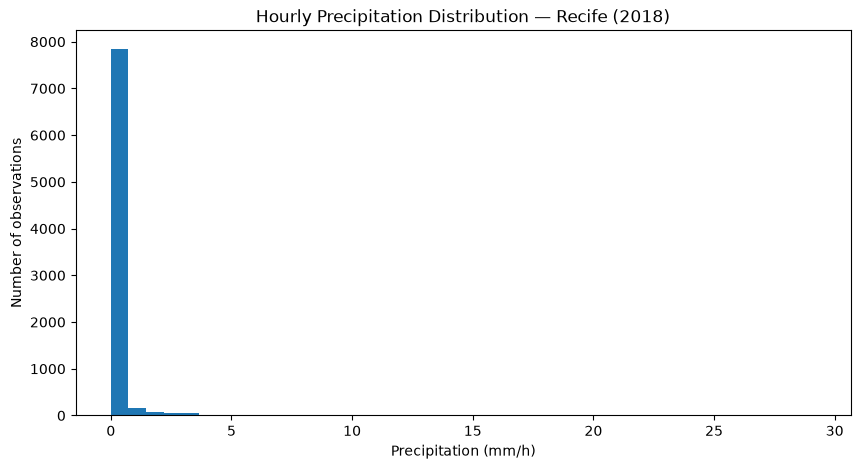

In [108]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_clean["precipitation_mm"],
    bins=40
)

plt.title("Hourly Precipitation Distribution — Recife (2018)")
plt.xlabel("Precipitation (mm/h)")
plt.ylabel("Number of observations")

plt.show()

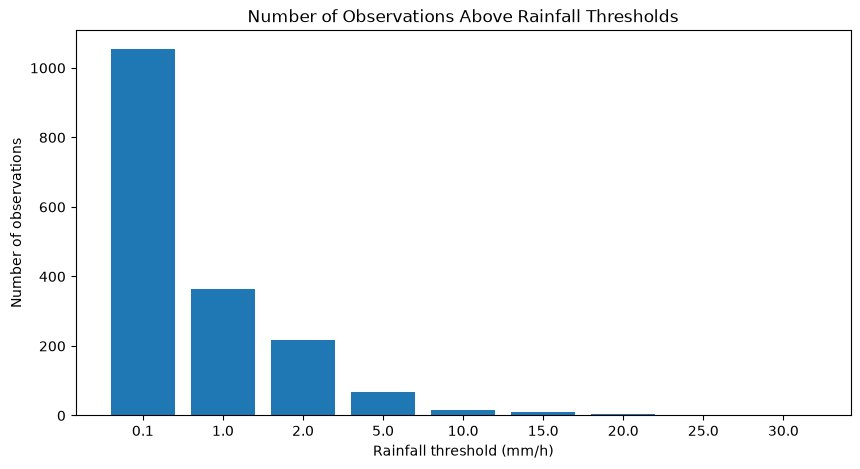

In [109]:
plt.figure(figsize=(10, 5))

plt.bar(
    threshold_df["threshold_mm_h"].astype(str),
    threshold_df["observations"]
)

plt.title("Number of Observations Above Rainfall Thresholds")
plt.xlabel("Rainfall threshold (mm/h)")
plt.ylabel("Number of observations")

plt.show()

## Audit Summary

In [110]:
expected_hours_2018 = len(full_2018_range)
observed_hours = len(df_clean)
missing_hours = len(missing_2018_timestamps)

print("=== DATASET AUDIT SUMMARY ===")
print()

print("Dataset dimensions")
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")
print()

print("Data quality")
print(f"Missing cell values: {df_clean.isna().sum().sum()}")
print(f"Duplicated rows: {df_clean.duplicated().sum()}")
print(f"Duplicated timestamps: {df_clean['datetime_utc'].duplicated().sum()}")
print()

print("Temporal coverage")
print(f"First observation: {df_clean['datetime_utc'].min()}")
print(f"Last observation: {df_clean['datetime_utc'].max()}")
print(f"Expected hours in 2018: {expected_hours_2018}")
print(f"Observed hours: {observed_hours}")
print(f"Missing hours: {missing_hours}")
print(f"Missing percentage: {(missing_hours / expected_hours_2018) * 100:.2f}%")
print(f"Temporal gaps: {len(temporal_gaps)}")
print()

print("Precipitation")
print(f"Rainy hours: {(df_clean['precipitation_mm'] > 0).sum()}")
print(f"Maximum hourly precipitation: {df_clean['precipitation_mm'].max():.2f} mm")

=== DATASET AUDIT SUMMARY ===

Dataset dimensions
Rows: 8279
Columns: 20

Data quality
Missing cell values: 1
Duplicated rows: 0
Duplicated timestamps: 0

Temporal coverage
First observation: 2018-01-03 13:00:00+00:00
Last observation: 2018-12-31 23:00:00+00:00
Expected hours in 2018: 8760
Observed hours: 8279
Missing hours: 481
Missing percentage: 5.49%
Temporal gaps: 19

Precipitation
Rainy hours: 1055
Maximum hourly precipitation: 29.20 mm


## Precipitation Analysis

This section analyzes the frequency and intensity of hourly precipitation events before defining the prediction target for the Machine Learning models.

In [111]:
precipitation = df_clean["precipitation_mm"]

rain_hours = (precipitation > 0).sum()
no_rain_hours = (precipitation == 0).sum()

print("=== PRECIPITATION SUMMARY ===")
print(f"Minimum precipitation: {precipitation.min():.2f} mm")
print(f"Maximum precipitation: {precipitation.max():.2f} mm")
print(f"Average precipitation: {precipitation.mean():.2f} mm")
print(f"Hours with rain: {rain_hours}")
print(f"Hours without rain: {no_rain_hours}")
print(f"Rainy hours percentage: {(rain_hours / len(df_clean)) * 100:.2f}%")

thresholds = [1, 2, 5, 10, 15, 20, 25, 30]

threshold_results = []

for threshold in thresholds:
    count = (precipitation >= threshold).sum()

    threshold_results.append({
        "threshold_mm_h": threshold,
        "observations": count,
        "percentage": (count / len(df_clean)) * 100
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

=== PRECIPITATION SUMMARY ===
Minimum precipitation: 0.00 mm
Maximum precipitation: 29.20 mm
Average precipitation: 0.19 mm
Hours with rain: 1055
Hours without rain: 7224
Rainy hours percentage: 12.74%


,threshold_mm_h,observations,percentage
0,1,365,4.408745
1,2,218,2.633168
2,5,67,0.809276
3,10,17,0.205339
4,15,9,0.108709
5,20,5,0.060394
6,25,2,0.024158
7,30,0,0.000000


## Precipitation Distribution and Audit Summary

The following visualizations show the distribution of hourly precipitation and the frequency of observations above different rainfall thresholds.

The final section consolidates the main findings of the initial dataset audit.

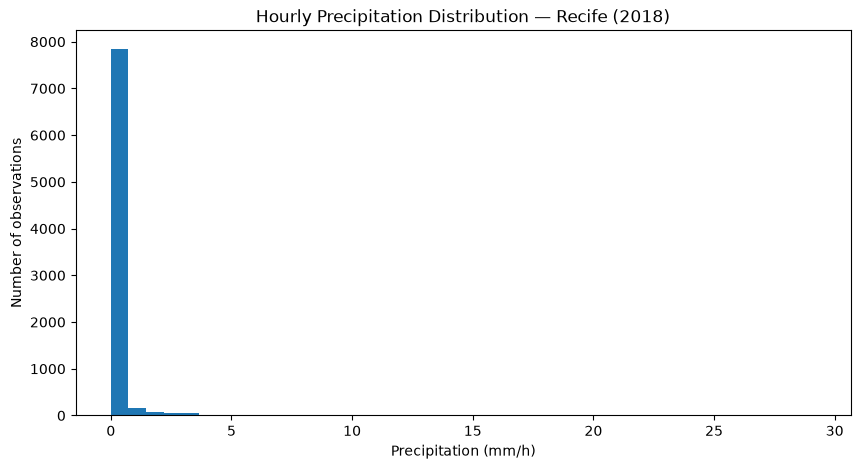

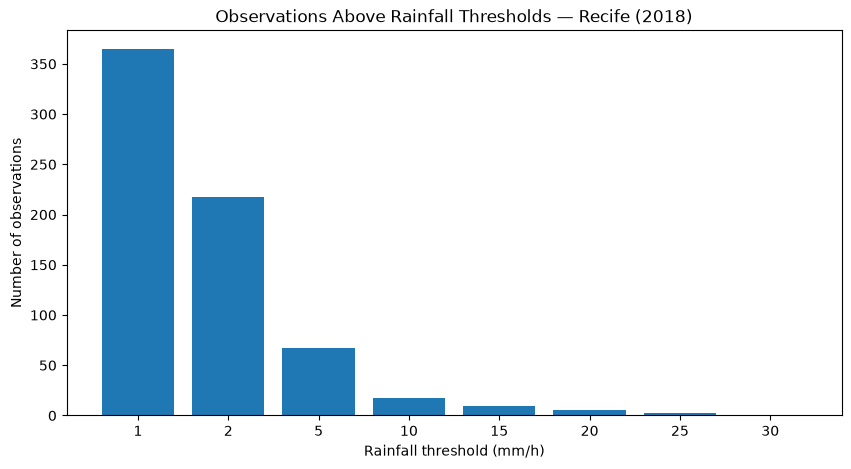

In [112]:
# Precipitation distribution

plt.figure(figsize=(10, 5))

plt.hist(
    df_clean["precipitation_mm"],
    bins=40
)

plt.title("Hourly Precipitation Distribution — Recife (2018)")
plt.xlabel("Precipitation (mm/h)")
plt.ylabel("Number of observations")

plt.show()


# Frequency by precipitation threshold

plt.figure(figsize=(10, 5))

plt.bar(
    threshold_df["threshold_mm_h"].astype(str),
    threshold_df["observations"]
)

plt.title("Observations Above Rainfall Thresholds — Recife (2018)")
plt.xlabel("Rainfall threshold (mm/h)")
plt.ylabel("Number of observations")

plt.show()

In [113]:
expected_hours_2018 = len(full_2018_range)
observed_hours = len(df_clean)
missing_hours = len(missing_2018_timestamps)

print("=== DATASET AUDIT SUMMARY ===")
print()

print("DATASET")
print(f"Rows: {df_clean.shape[0]}")
print(f"Original meteorological variables: 18")
print()

print("DATA QUALITY")
print(f"Duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated timestamps: {df_clean['datetime_utc'].duplicated().sum()}")
print(f"Numeric conversion failures: {conversion_missing.sum()}")
print()

print("TEMPORAL COVERAGE")
print(f"First observation: {df_clean['datetime_utc'].min()}")
print(f"Last observation: {df_clean['datetime_utc'].max()}")
print(f"Expected hours in 2018: {expected_hours_2018}")
print(f"Observed hours: {observed_hours}")
print(f"Missing hours: {missing_hours}")
print(f"Missing percentage: {(missing_hours / expected_hours_2018) * 100:.2f}%")
print(f"Temporal gaps: {len(temporal_gaps)}")
print()

print("PRECIPITATION")
print(f"Hours with rain: {(df_clean['precipitation_mm'] > 0).sum()}")
print(f"Hours without rain: {(df_clean['precipitation_mm'] == 0).sum()}")
print(f"Maximum hourly precipitation: {df_clean['precipitation_mm'].max():.2f} mm")

=== DATASET AUDIT SUMMARY ===

DATASET
Rows: 8279
Original meteorological variables: 18

DATA QUALITY
Duplicated rows: 0
Duplicated timestamps: 0
Numeric conversion failures: 0

TEMPORAL COVERAGE
First observation: 2018-01-03 13:00:00+00:00
Last observation: 2018-12-31 23:00:00+00:00
Expected hours in 2018: 8760
Observed hours: 8279
Missing hours: 481
Missing percentage: 5.49%
Temporal gaps: 19

PRECIPITATION
Hours with rain: 1055
Hours without rain: 7224
Maximum hourly precipitation: 29.20 mm


## Conclusion

The initial audit confirms that the dataset can be loaded and standardized successfully, with no duplicated observations and no failures during numeric conversion.

However, the temporal analysis identified missing hourly observations during 2018. These gaps must be considered during preprocessing and especially when constructing future prediction targets, because consecutive rows do not always represent consecutive hours.

The precipitation analysis also indicates that intense rainfall events are substantially less frequent than dry or low-rainfall observations. This class imbalance must be considered when defining the prediction target and evaluating Machine Learning models.

The next stage of the project will focus on data preprocessing and preparation for feature engineering.